<a href="https://www.kaggle.com/code/omborse771924/house-price-prediction-analysis-eda?scriptVersionId=340812577" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/debayank2024/house-price-prediction/modified_data.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/debayank2024/house-price-prediction/modified_data.csv')

In [3]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


In [4]:
df.tail()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
4595,2014-07-09,308166.67,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,204.08
4596,2014-07-09,534333.33,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,365.98
4597,2014-07-09,416904.17,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,138.51
4598,2014-07-10,203400.00,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,97.32
4599,2014-07-10,220600.00,3.0,2.50,1490,8102,2.0,0,0,4,1490,0,1990,0,18717 SE 258th St,Covington,WA 98042,148.05


In [5]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price_per_sqft
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261,265.876209
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536,357.503362
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,180.817500
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,243.855000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000,314.840000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000,22533.900000


In [6]:
df.info

<bound method DataFrame.info of             date       price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0     2014-05-02   313000.00       3.0       1.50         1340      7912   
1     2014-05-02  2384000.00       5.0       2.50         3650      9050   
2     2014-05-02   342000.00       3.0       2.00         1930     11947   
3     2014-05-02   420000.00       3.0       2.25         2000      8030   
4     2014-05-02   550000.00       4.0       2.50         1940     10500   
...          ...         ...       ...        ...          ...       ...   
4595  2014-07-09   308166.67       3.0       1.75         1510      6360   
4596  2014-07-09   534333.33       3.0       2.50         1460      7573   
4597  2014-07-09   416904.17       3.0       2.50         3010      7014   
4598  2014-07-10   203400.00       4.0       2.00         2090      6630   
4599  2014-07-10   220600.00       3.0       2.50         1490      8102   

      floors  waterfront  view  condition  sqft_above  

In [7]:
df.isnull()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4596,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4597,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4598,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

date              0
price             0
bedrooms          0
bathrooms         0
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
street            0
city              0
statezip          0
price_per_sqft    0
dtype: int64

In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4595    False
4596    False
4597    False
4598    False
4599    False
Length: 4600, dtype: bool

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'price_per_sqft'],
      dtype='object')

## EDA

              price     bedrooms    bathrooms   sqft_living      sqft_lot  \
count  4.600000e+03  4600.000000  4600.000000   4600.000000  4.600000e+03   
mean   5.519630e+05     3.400870     2.160815   2139.346957  1.485252e+04   
std    5.638347e+05     0.908848     0.783781    963.206916  3.588444e+04   
min    0.000000e+00     0.000000     0.000000    370.000000  6.380000e+02   
25%    3.228750e+05     3.000000     1.750000   1460.000000  5.000750e+03   
50%    4.609435e+05     3.000000     2.250000   1980.000000  7.683000e+03   
75%    6.549625e+05     4.000000     2.500000   2620.000000  1.100125e+04   
max    2.659000e+07     9.000000     8.000000  13540.000000  1.074218e+06   

            floors   waterfront         view    condition   sqft_above  \
count  4600.000000  4600.000000  4600.000000  4600.000000  4600.000000   
mean      1.512065     0.007174     0.240652     3.451739  1827.265435   
std       0.538288     0.084404     0.778405     0.677230   862.168977   
min       

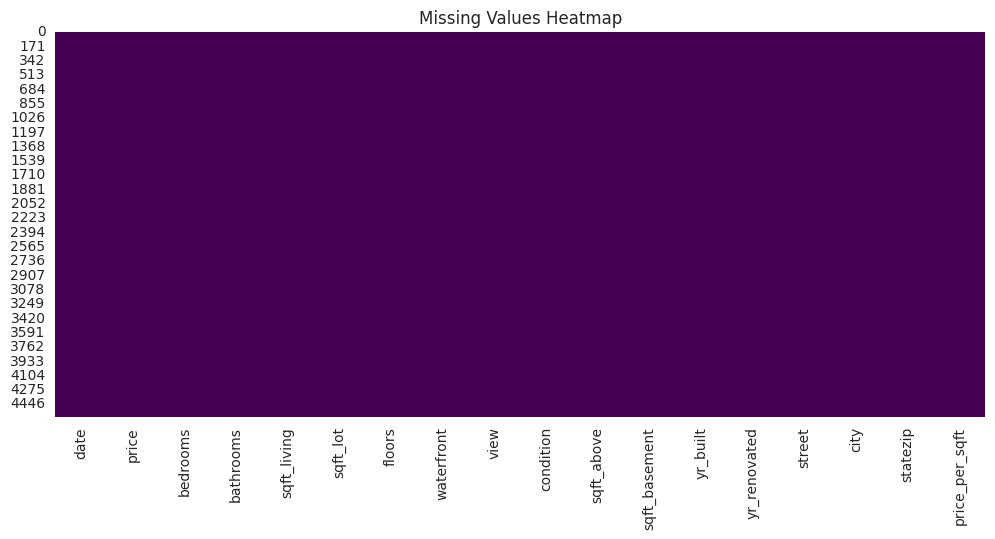

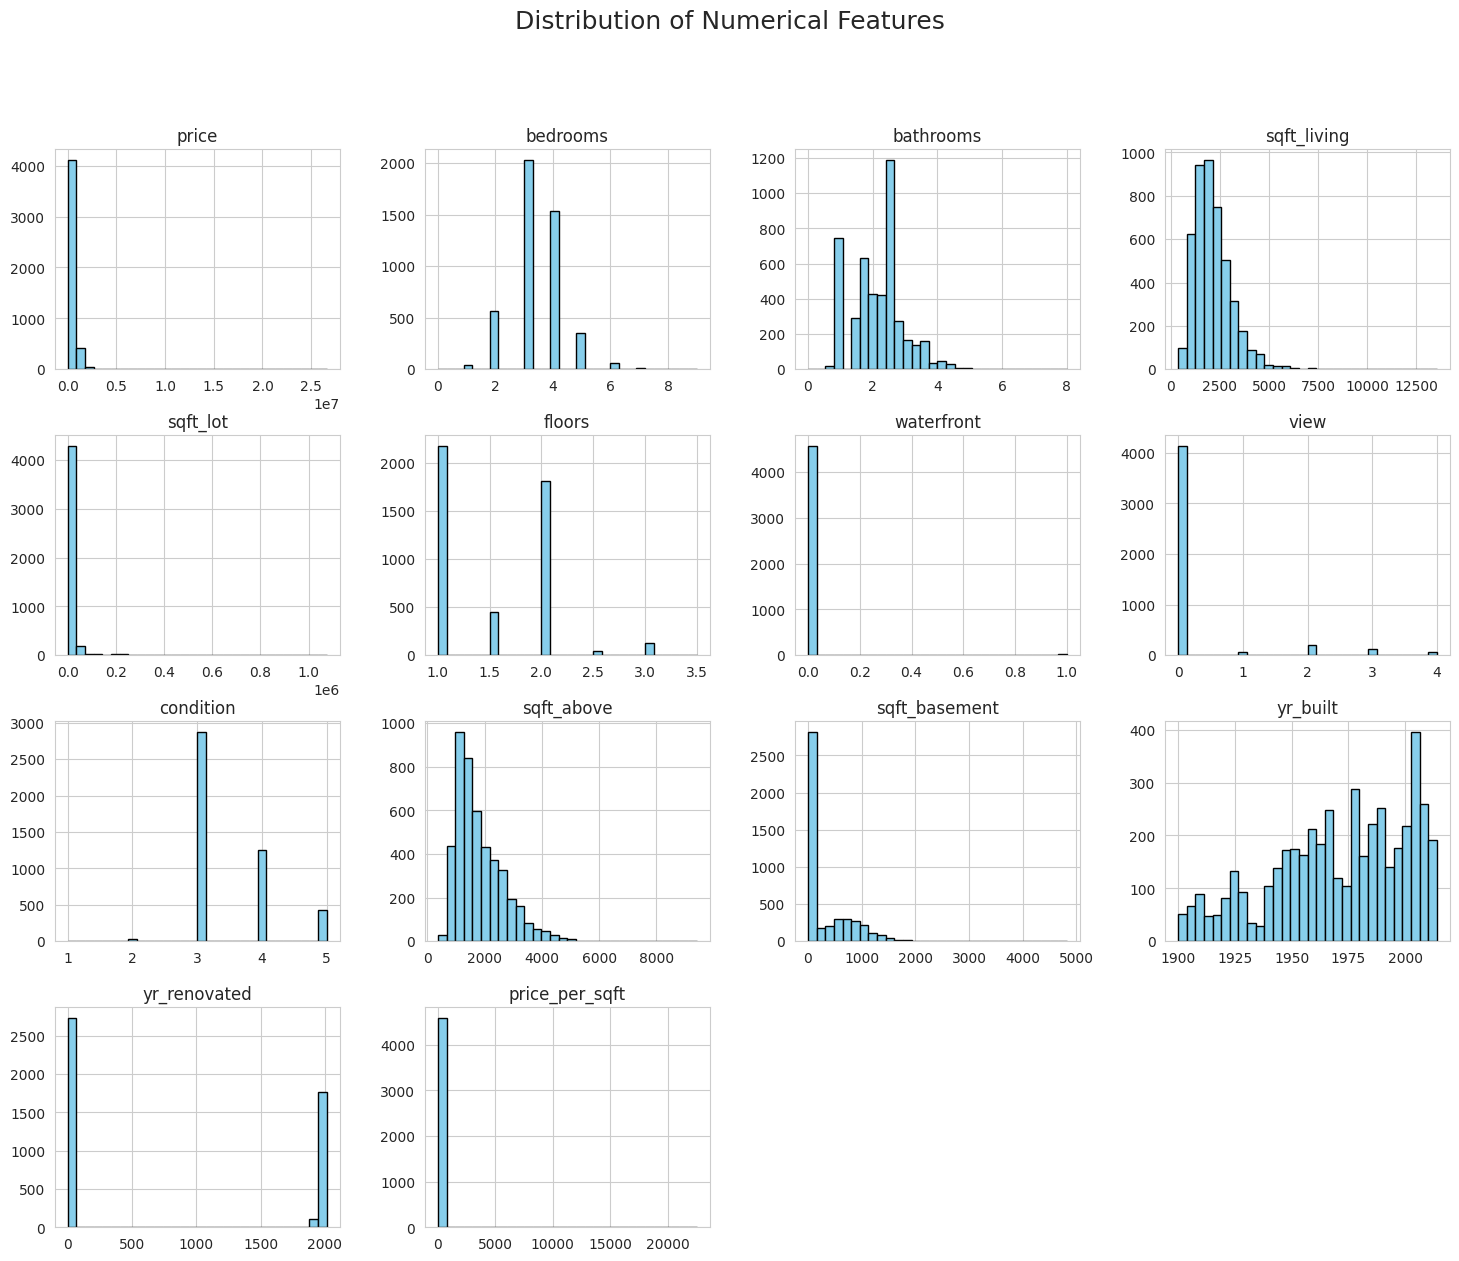

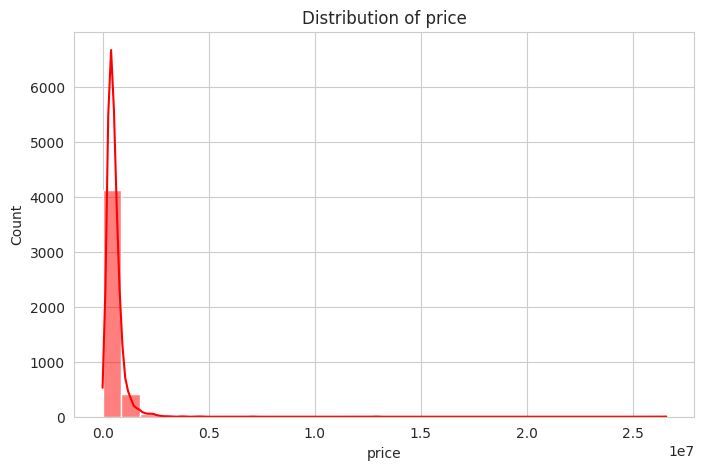

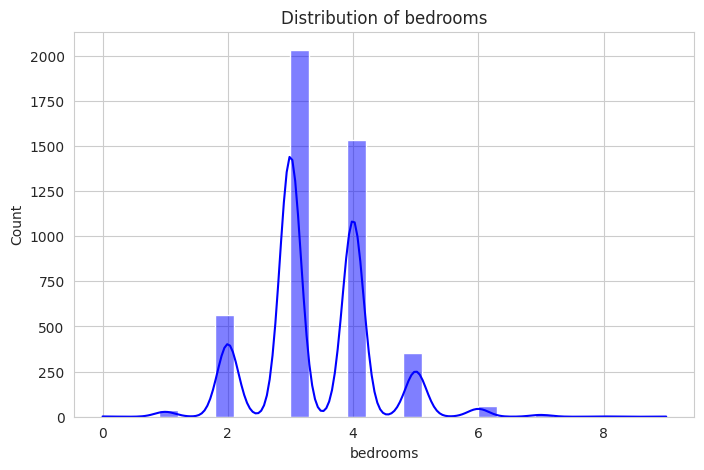

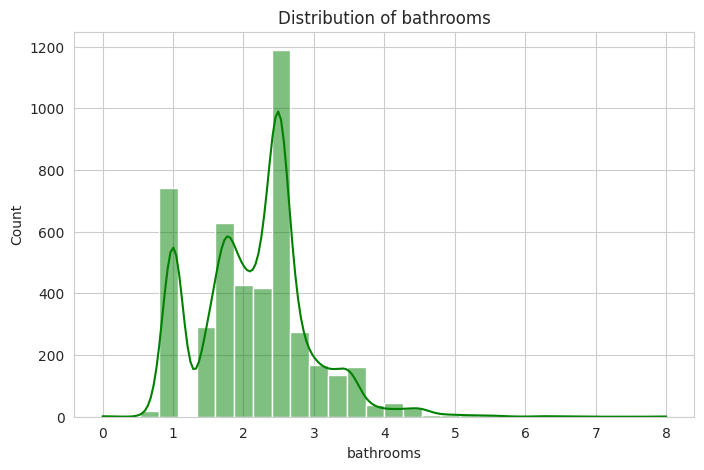

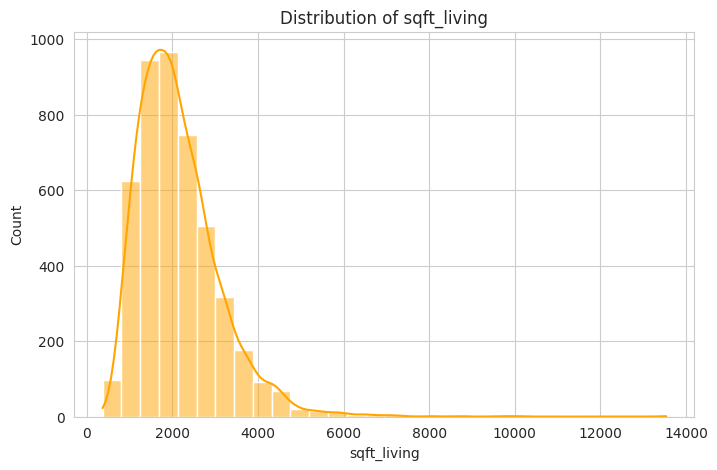

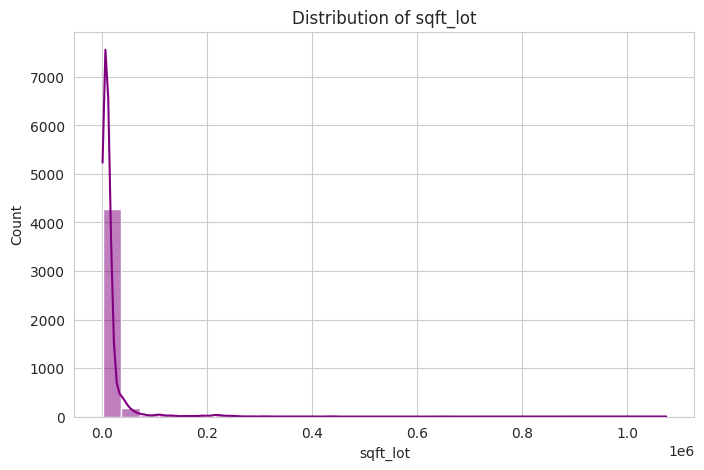

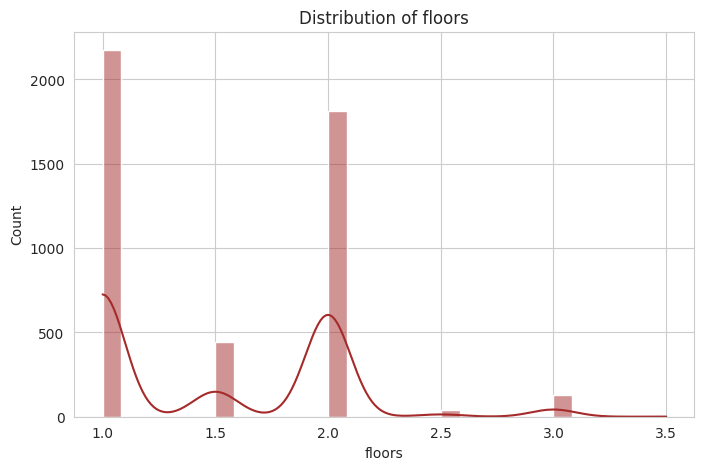

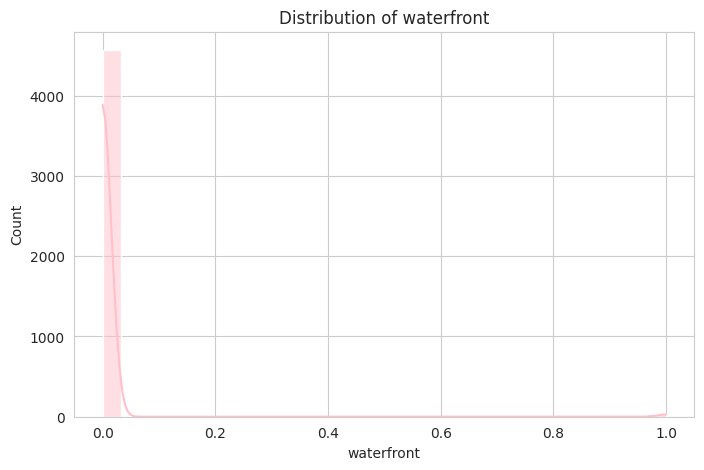

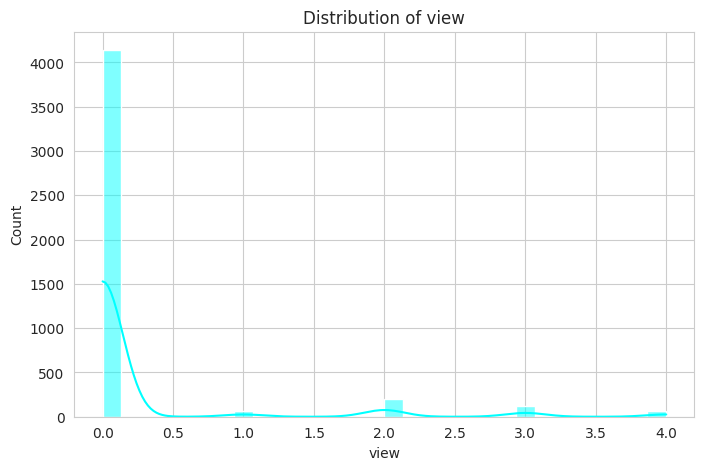

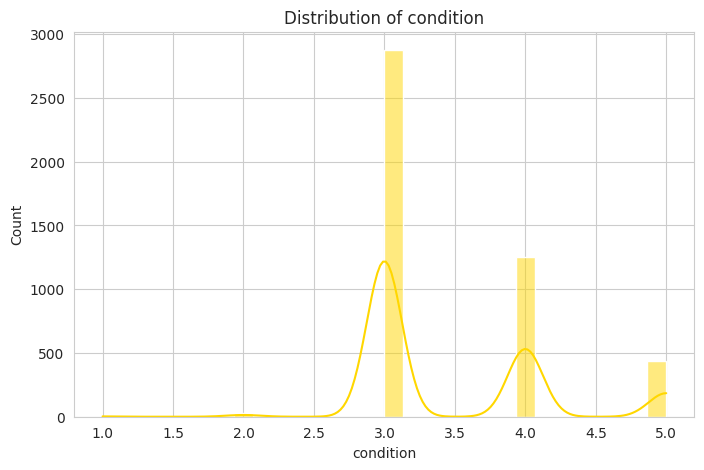

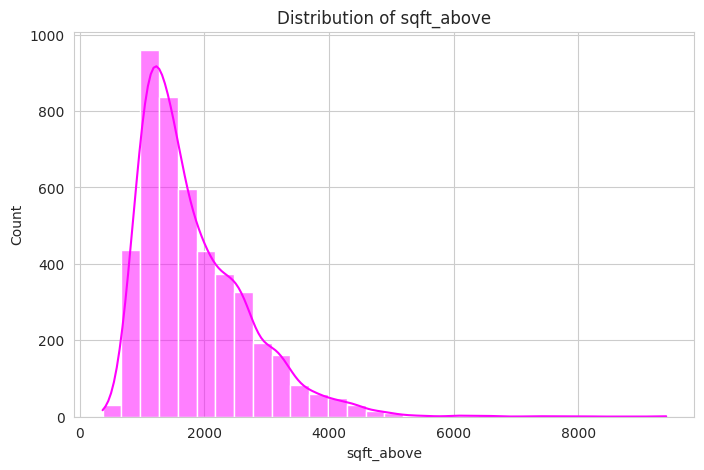

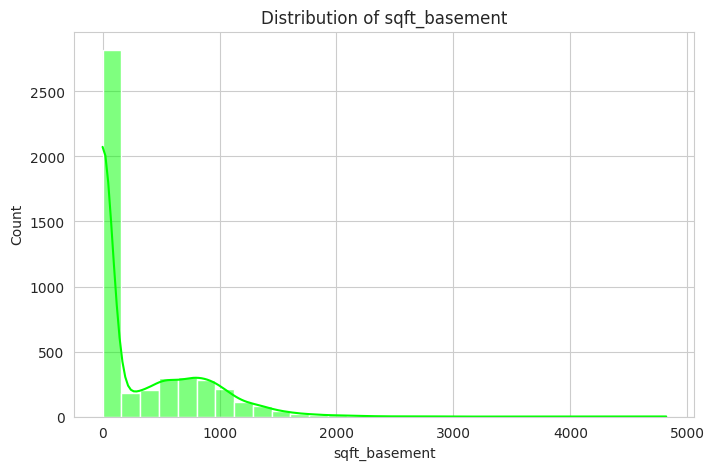

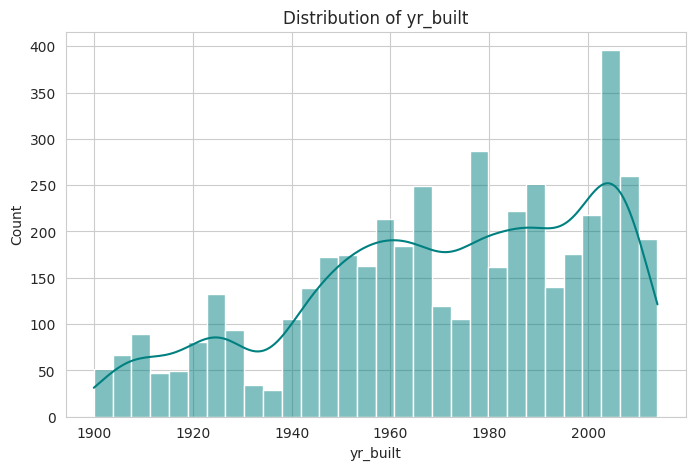

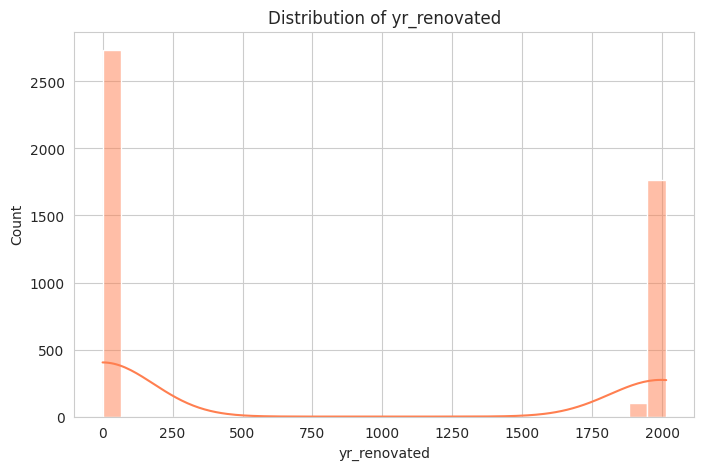

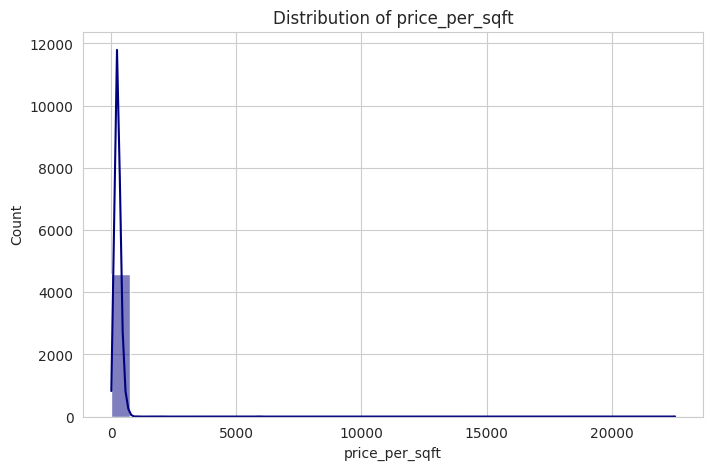

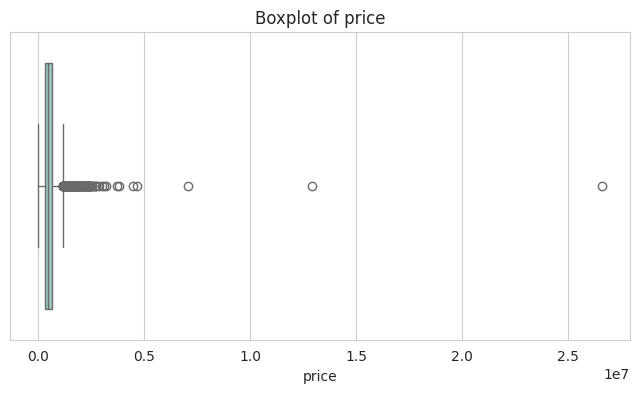

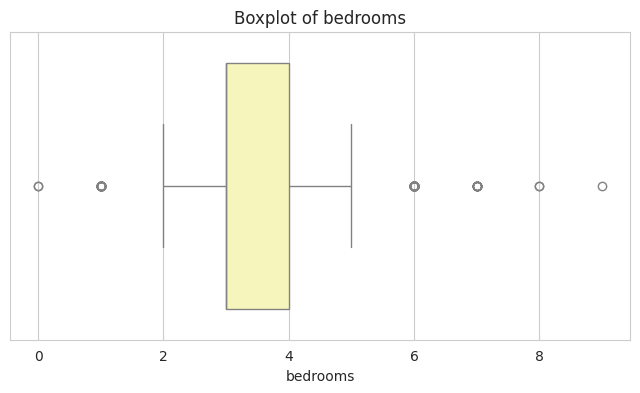

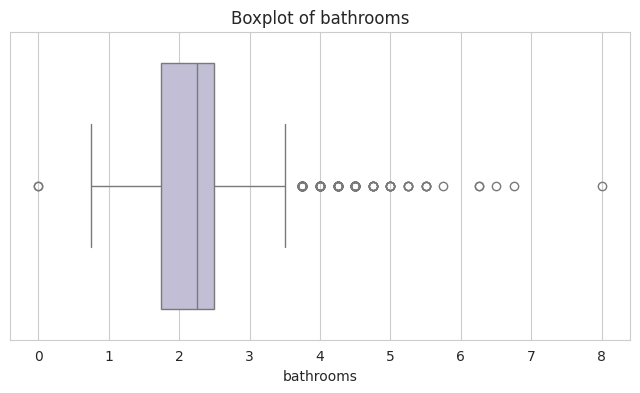

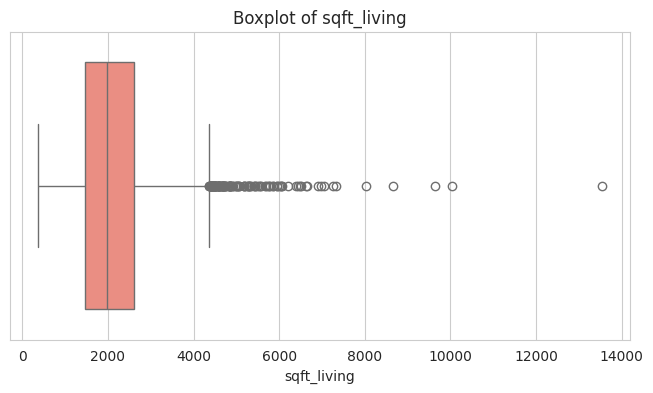

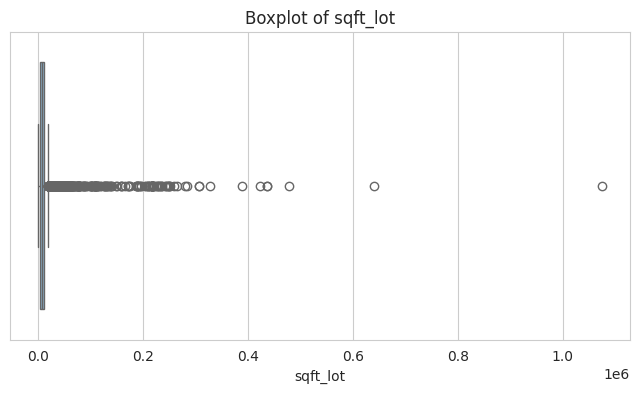

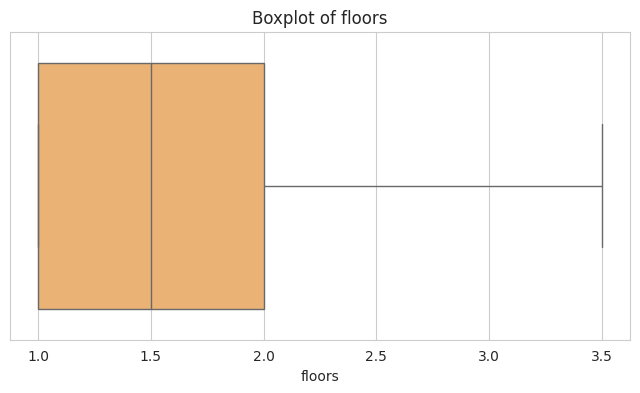

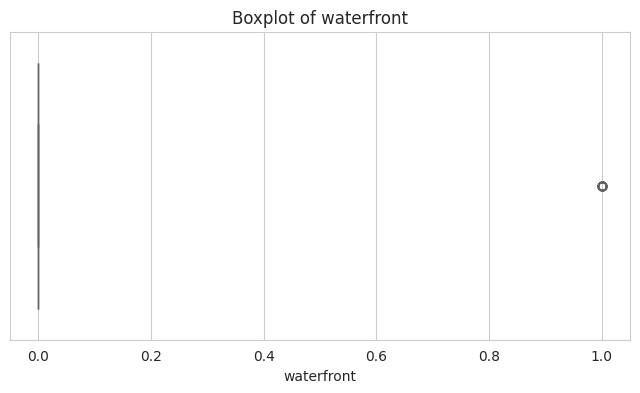

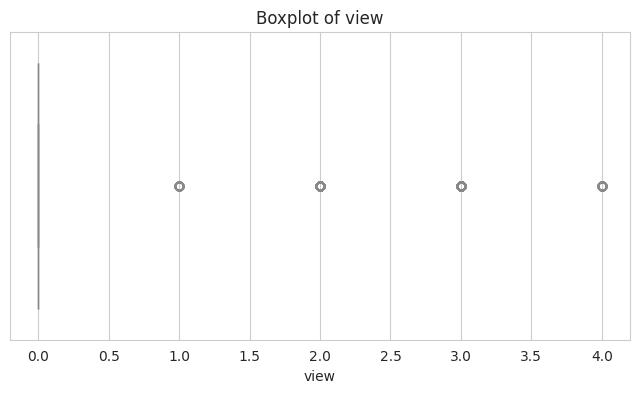

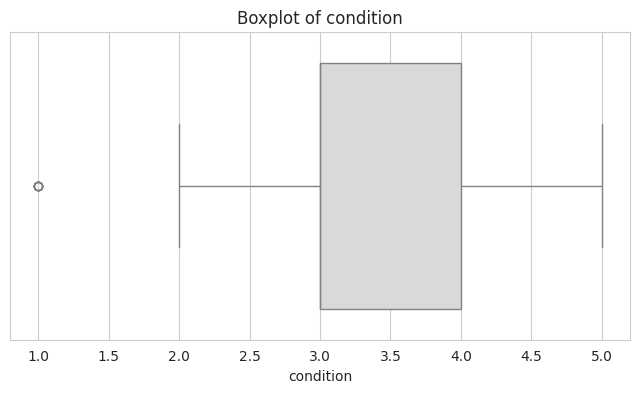

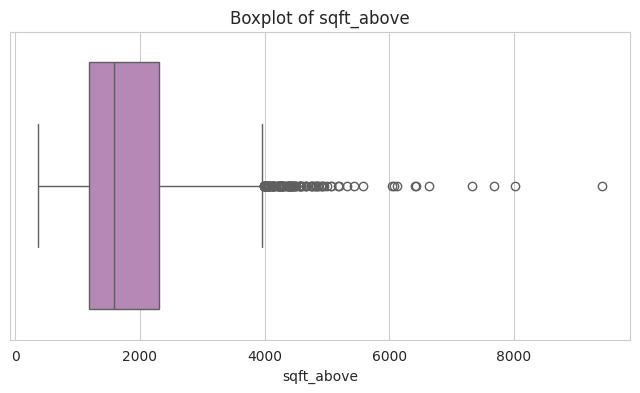

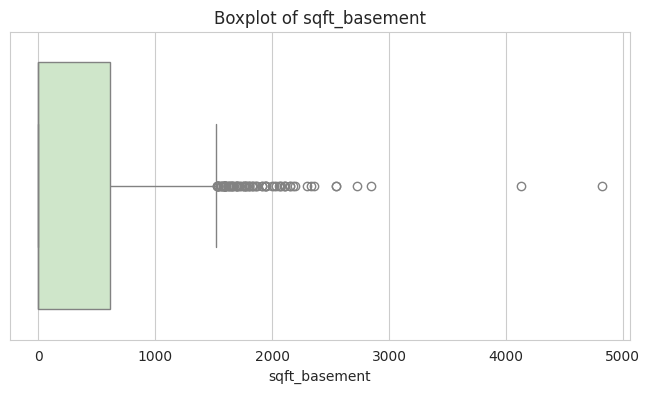

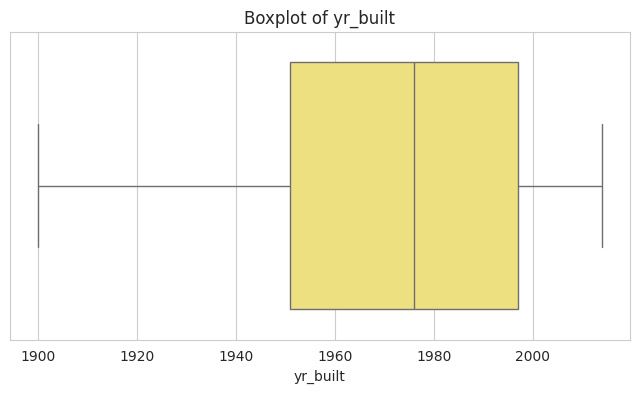

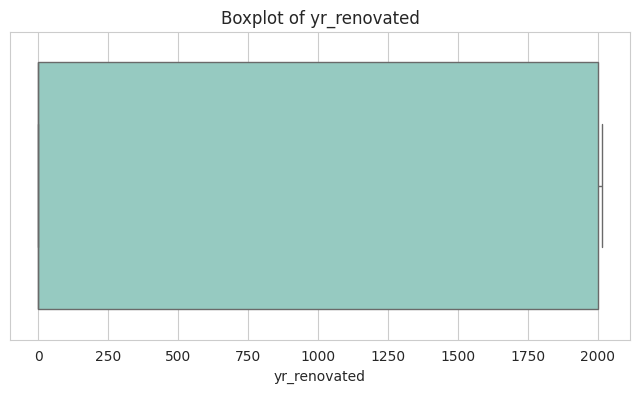

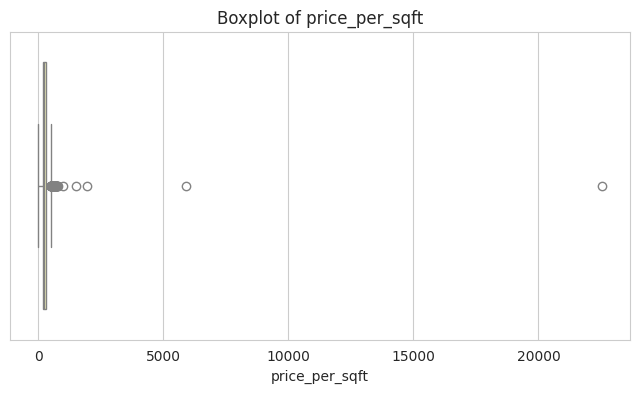

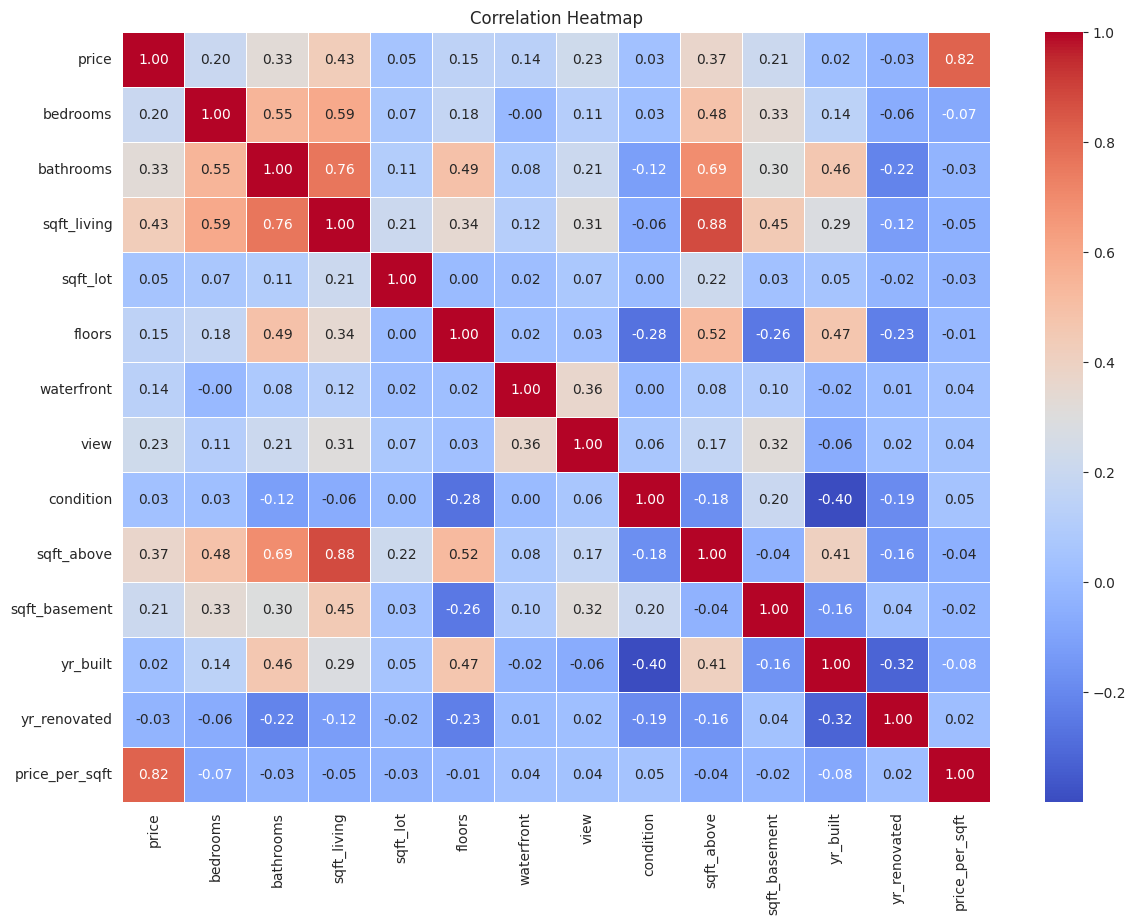

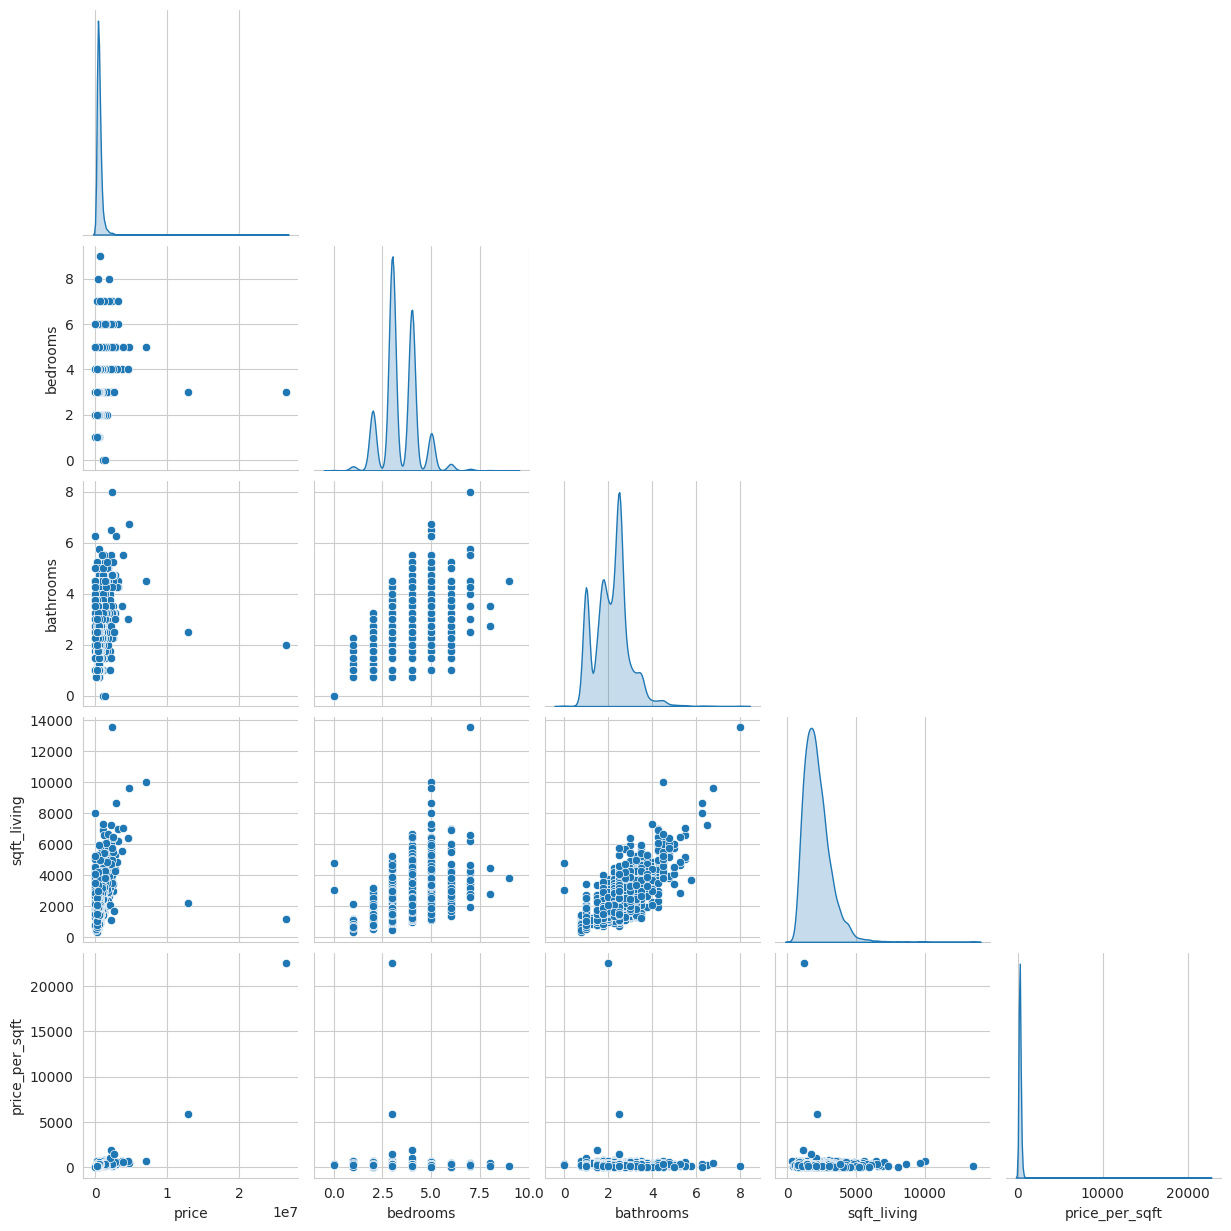

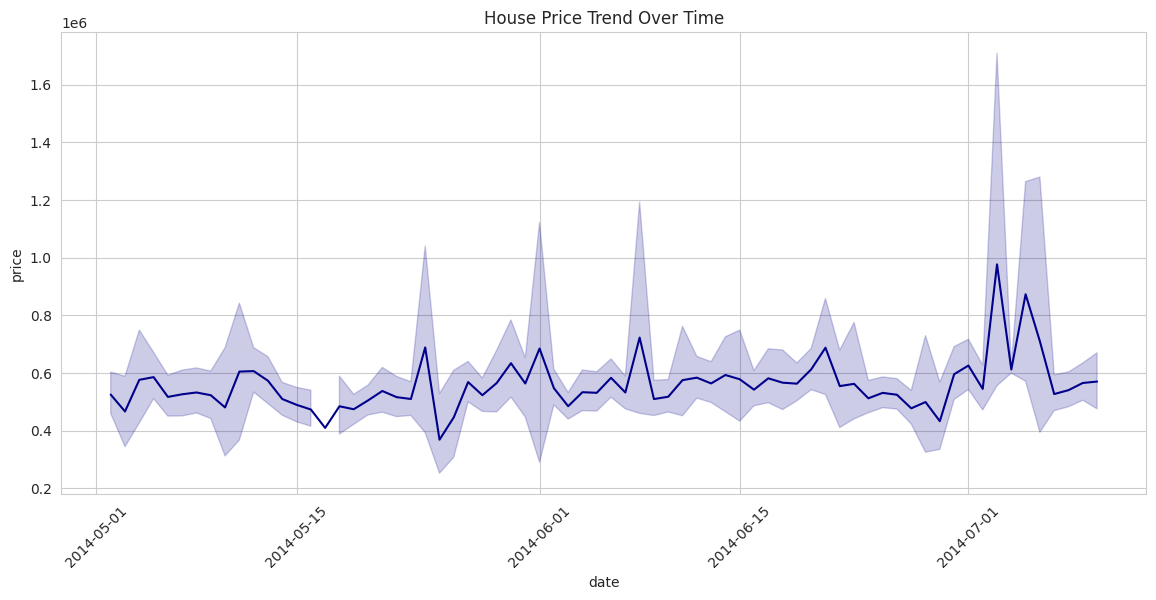

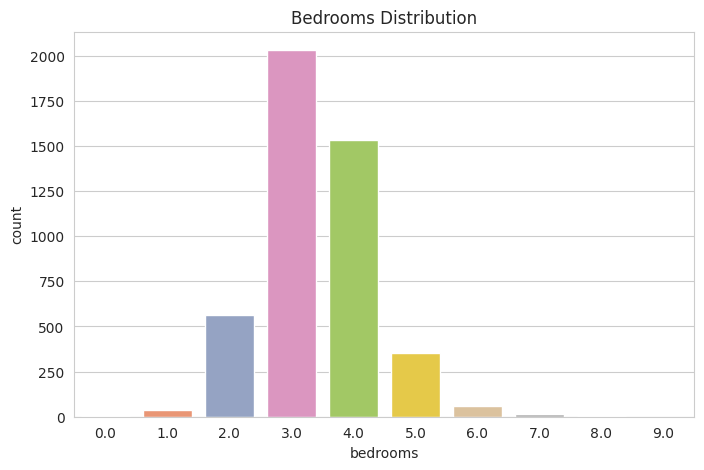

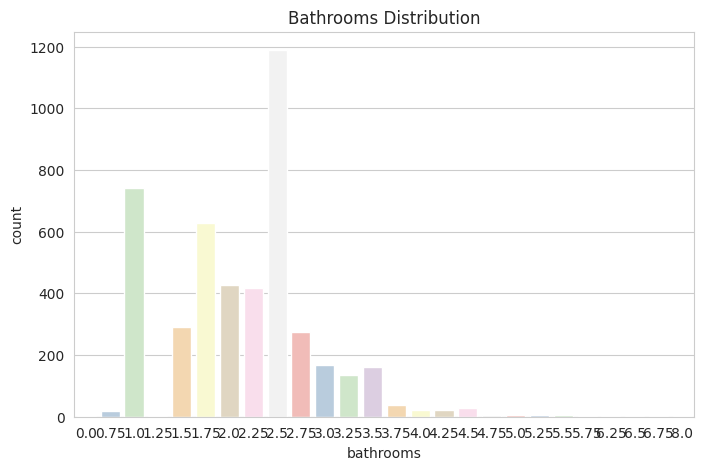

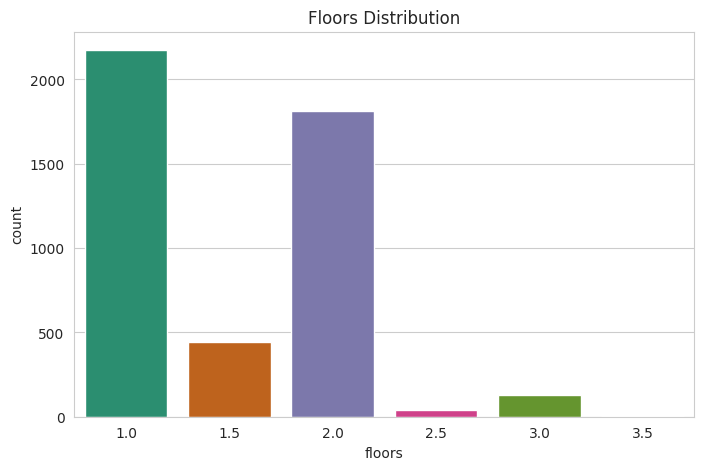

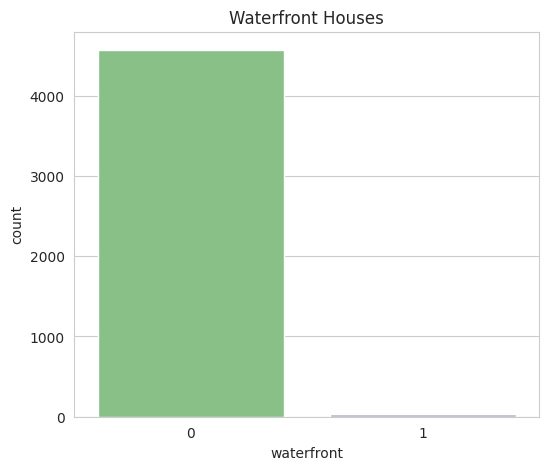

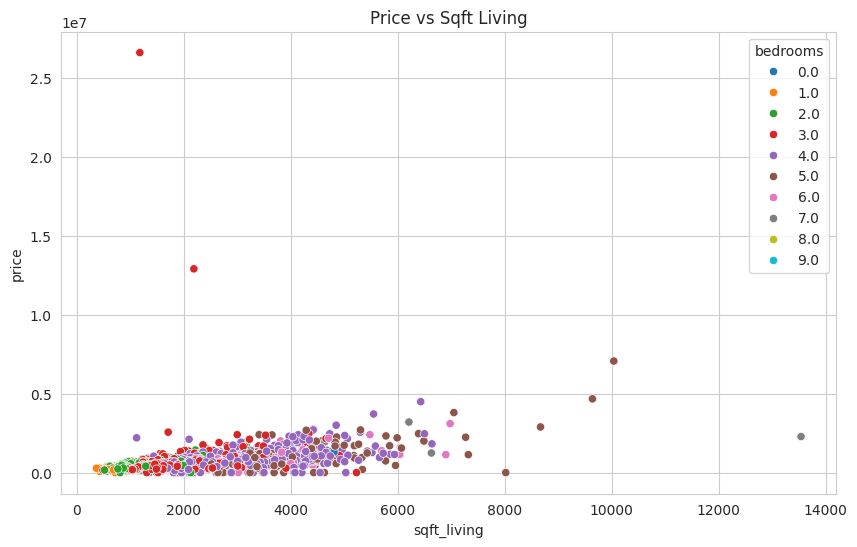

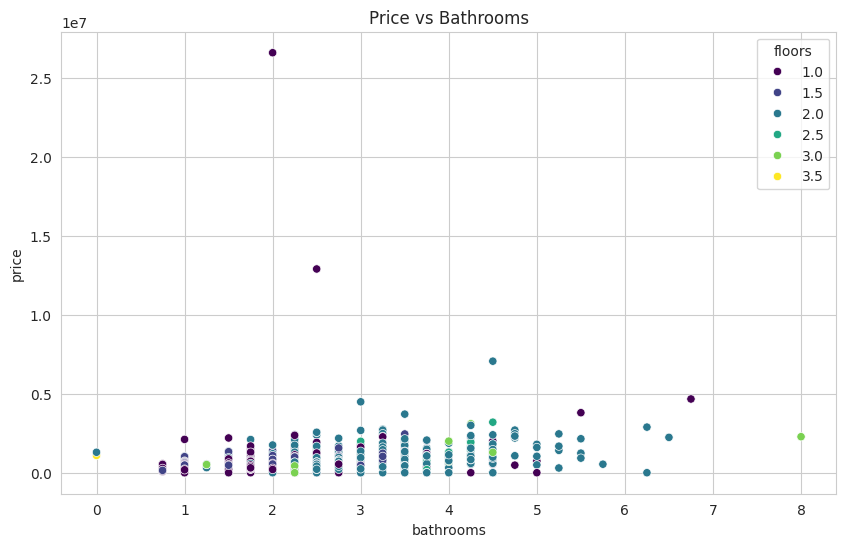

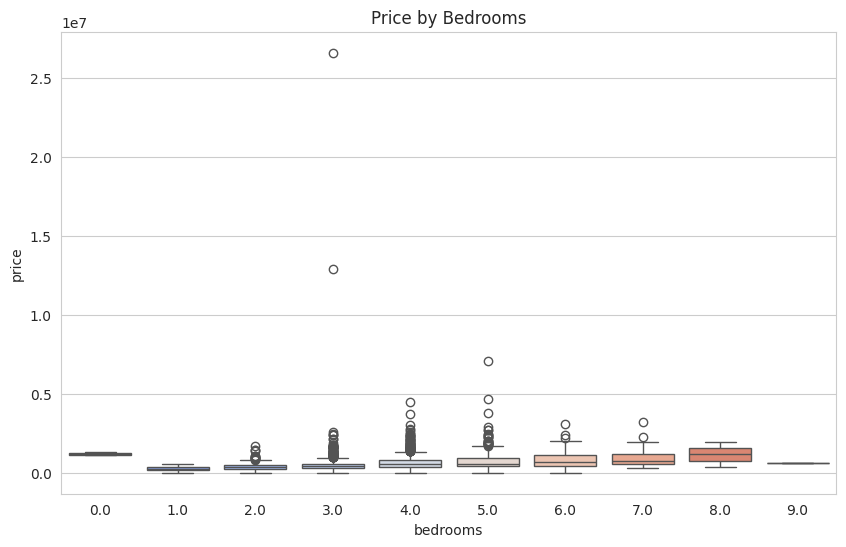

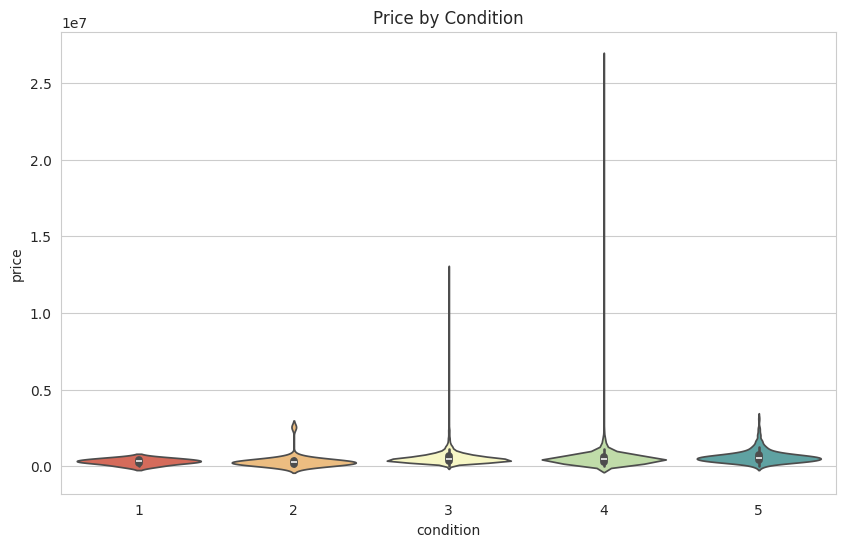

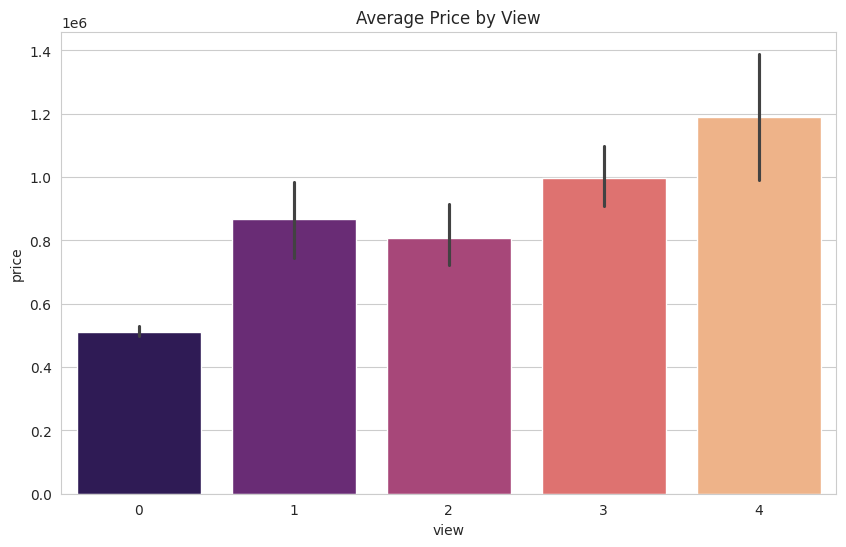

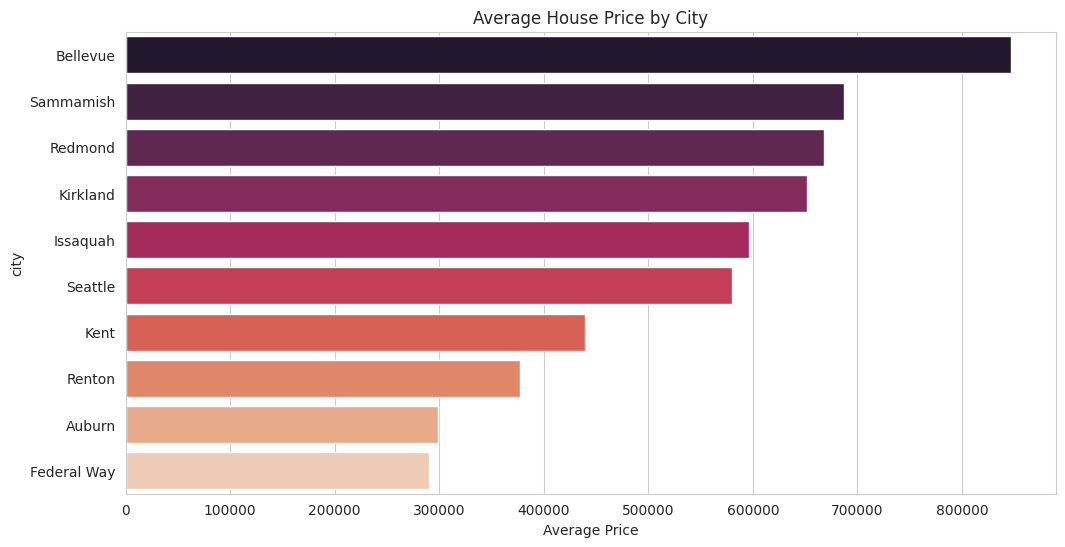

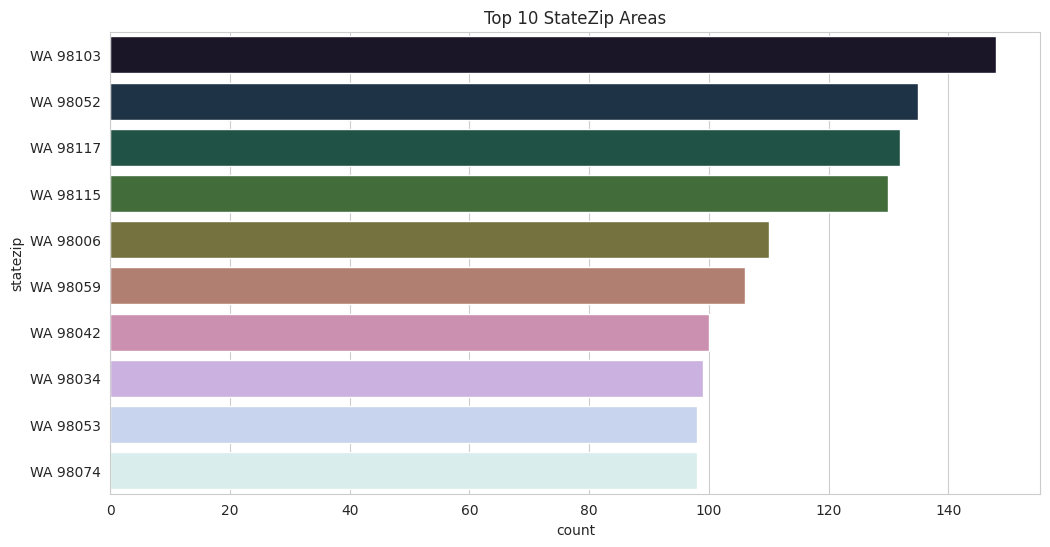

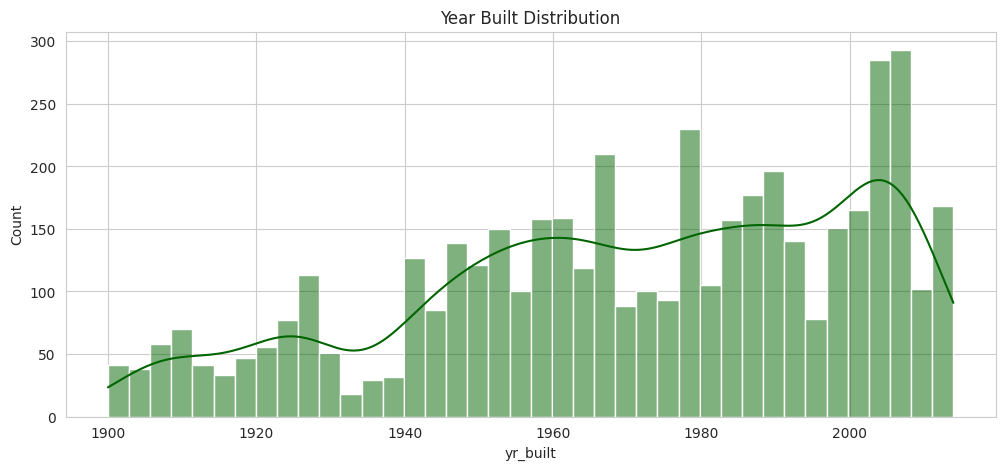

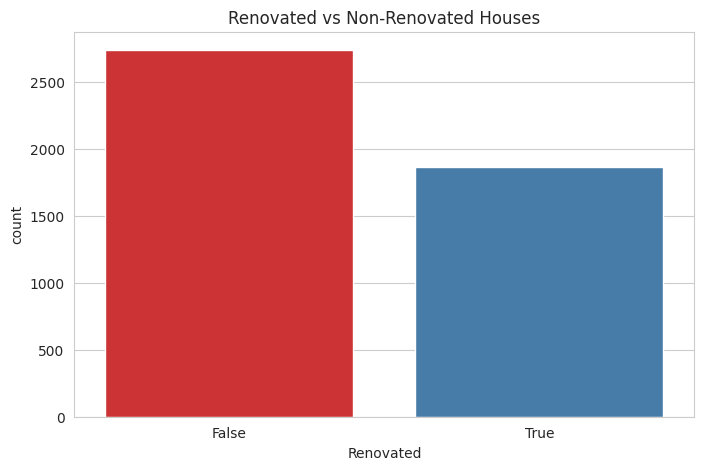

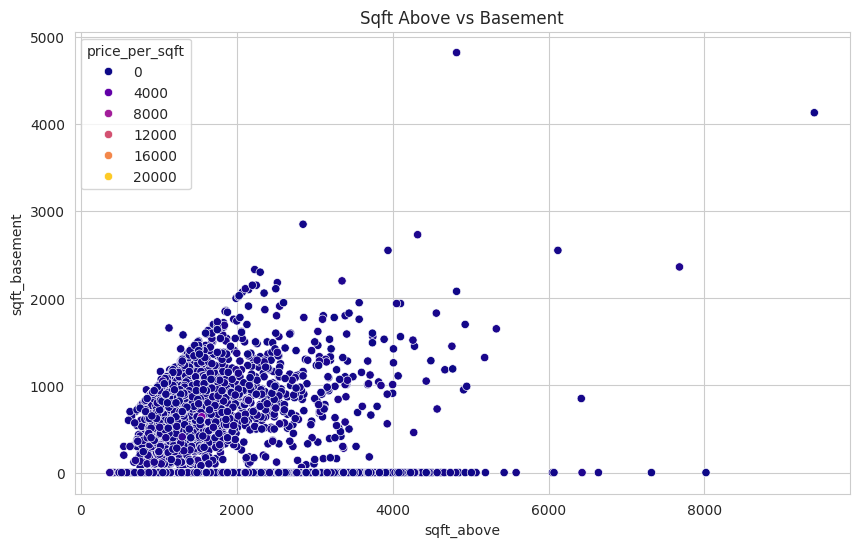

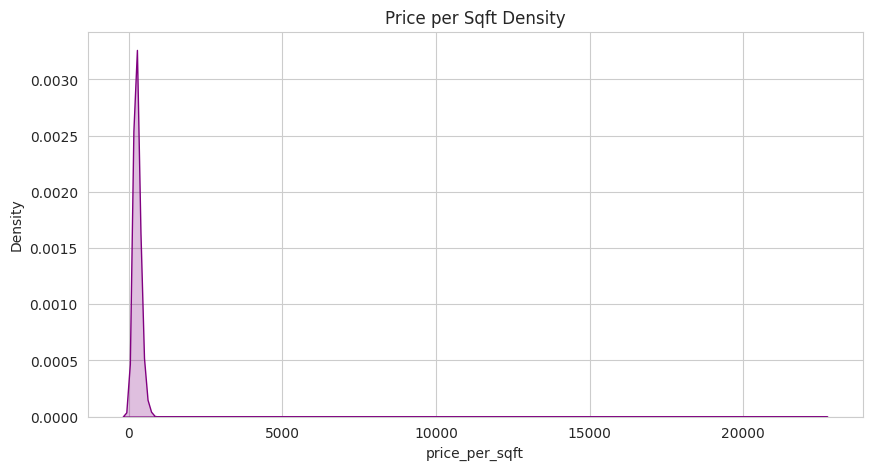

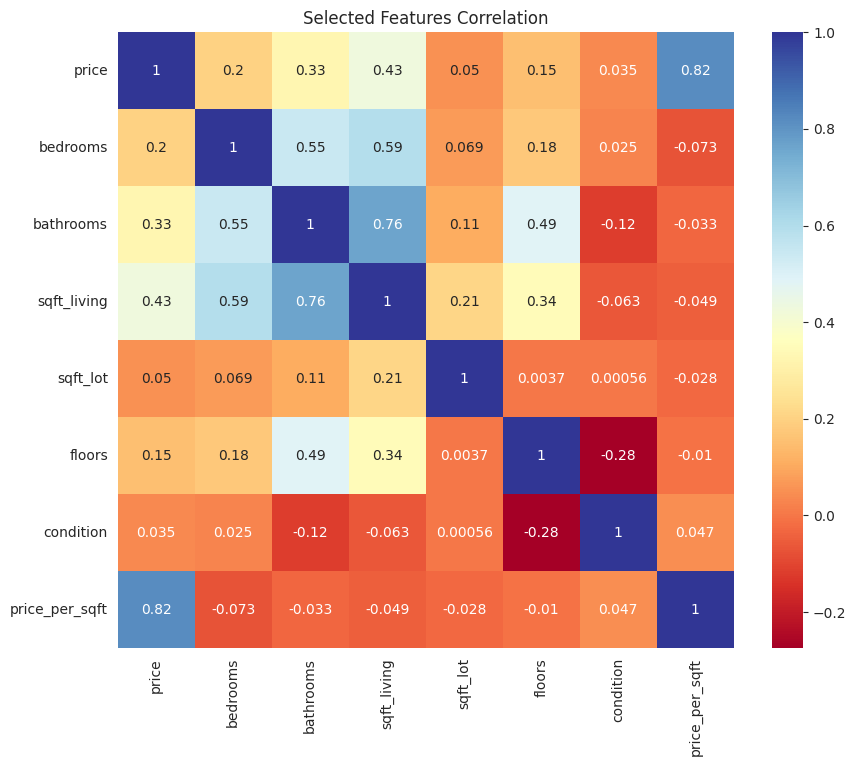

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# STYLE
# =========================================

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# =========================================
# COPY DATA
# =========================================

data = df.copy()

# =========================================
# DATE CONVERSION
# =========================================

data["date"] = pd.to_datetime(data["date"], errors="coerce")

# =========================================
# NUMERIC COLUMNS
# =========================================

num_cols = [
    "price",
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "sqft_above",
    "sqft_basement",
    "yr_built",
    "yr_renovated",
    "price_per_sqft"
]

# =========================================
# DATASET OVERVIEW
# =========================================

print(data[num_cols].describe())

# =========================================
# MISSING VALUE HEATMAP
# =========================================

plt.figure(figsize=(12, 5))
sns.heatmap(data.isnull(), cmap="viridis", cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

# =========================================
# HISTOGRAMS
# =========================================

data[num_cols].hist(
    bins=30,
    figsize=(18, 14),
    color="skyblue",
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features", fontsize=18)
plt.show()

# =========================================
# INDIVIDUAL DISTRIBUTIONS
# =========================================

colors = [
    "red", "blue", "green", "orange", "purple",
    "brown", "pink", "cyan", "gold", "magenta",
    "lime", "teal", "coral", "navy"
]

for col, color in zip(num_cols, colors):

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data[col],
        kde=True,
        bins=30,
        color=color
    )

    plt.title(f"Distribution of {col}")
    plt.show()

# =========================================
# BOXPLOTS
# =========================================

palette = sns.color_palette("Set3", len(num_cols))

for col, color in zip(num_cols, palette):

    plt.figure(figsize=(8, 4))

    sns.boxplot(x=data[col], color=color)

    plt.title(f"Boxplot of {col}")
    plt.show()

# =========================================
# CORRELATION HEATMAP
# =========================================

plt.figure(figsize=(14, 10))

sns.heatmap(
    data[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

# =========================================
# PAIRPLOT
# =========================================

sns.pairplot(
    data[[
        "price",
        "bedrooms",
        "bathrooms",
        "sqft_living",
        "price_per_sqft"
    ]],
    diag_kind="kde",
    corner=True
)

plt.show()

# =========================================
# PRICE TREND OVER TIME
# =========================================

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=data.sort_values("date"),
    x="date",
    y="price",
    color="darkblue"
)

plt.title("House Price Trend Over Time")
plt.xticks(rotation=45)
plt.show()

# =========================================
# BEDROOMS DISTRIBUTION
# =========================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="bedrooms",
    palette="Set2"
)

plt.title("Bedrooms Distribution")
plt.show()

# =========================================
# BATHROOMS DISTRIBUTION
# =========================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="bathrooms",
    palette="Pastel1"
)

plt.title("Bathrooms Distribution")
plt.show()

# =========================================
# FLOORS DISTRIBUTION
# =========================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="floors",
    palette="Dark2"
)

plt.title("Floors Distribution")
plt.show()

# =========================================
# WATERFRONT HOUSES
# =========================================

plt.figure(figsize=(6, 5))

sns.countplot(
    data=data,
    x="waterfront",
    palette="Accent"
)

plt.title("Waterfront Houses")
plt.show()

# =========================================
# PRICE VS SQFT LIVING
# =========================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="sqft_living",
    y="price",
    hue="bedrooms",
    palette="tab10"
)

plt.title("Price vs Sqft Living")
plt.show()

# =========================================
# PRICE VS BATHROOMS
# =========================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="bathrooms",
    y="price",
    hue="floors",
    palette="viridis"
)

plt.title("Price vs Bathrooms")
plt.show()

# =========================================
# PRICE BY BEDROOMS
# =========================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x="bedrooms",
    y="price",
    palette="coolwarm"
)

plt.title("Price by Bedrooms")
plt.show()

# =========================================
# PRICE BY CONDITION
# =========================================

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=data,
    x="condition",
    y="price",
    palette="Spectral"
)

plt.title("Price by Condition")
plt.show()

# =========================================
# PRICE BY VIEW
# =========================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=data,
    x="view",
    y="price",
    estimator="mean",
    palette="magma"
)

plt.title("Average Price by View")
plt.show()

# =========================================
# CITY-WISE AVERAGE PRICE
# =========================================

top_cities = data["city"].value_counts().head(10).index

city_avg = (
    data[data["city"].isin(top_cities)]
    .groupby("city")["price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=city_avg.values,
    y=city_avg.index,
    palette="rocket"
)

plt.title("Average House Price by City")
plt.xlabel("Average Price")
plt.show()

# =========================================
# STATEZIP TOP 10
# =========================================

plt.figure(figsize=(12, 6))

sns.countplot(
    data=data,
    y="statezip",
    order=data["statezip"].value_counts().head(10).index,
    palette="cubehelix"
)

plt.title("Top 10 StateZip Areas")
plt.show()

# =========================================
# YEAR BUILT DISTRIBUTION
# =========================================

plt.figure(figsize=(12, 5))

sns.histplot(
    data["yr_built"],
    bins=40,
    kde=True,
    color="darkgreen"
)

plt.title("Year Built Distribution")
plt.show()

# =========================================
# RENOVATION ANALYSIS
# =========================================

plt.figure(figsize=(8, 5))

sns.countplot(
    x=(data["yr_renovated"] > 0),
    palette="Set1"
)

plt.title("Renovated vs Non-Renovated Houses")
plt.xlabel("Renovated")
plt.show()

# =========================================
# SQFT ABOVE VS BASEMENT
# =========================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="sqft_above",
    y="sqft_basement",
    hue="price_per_sqft",
    palette="plasma"
)

plt.title("Sqft Above vs Basement")
plt.show()

# =========================================
# PRICE PER SQFT DISTRIBUTION
# =========================================

plt.figure(figsize=(10, 5))

sns.kdeplot(
    data=data,
    x="price_per_sqft",
    fill=True,
    color="purple"
)

plt.title("Price per Sqft Density")
plt.show()

# =========================================
# HEATMAP OF SELECTED FEATURES
# =========================================

selected = [
    "price",
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "condition",
    "price_per_sqft"
]

plt.figure(figsize=(10, 8))

sns.heatmap(
    data[selected].corr(),
    annot=True,
    cmap="RdYlBu",
    square=True
)

plt.title("Selected Features Correlation")
plt.show()

## Faetures Engineering

Logistic Regression
Accuracy : 0.912
Precision: 0.9075
Recall   : 0.9174
F1 Score : 0.9124
ROC AUC  : 0.971

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.91      0.91       460
           1       0.91      0.92      0.91       460

    accuracy                           0.91       920
   macro avg       0.91      0.91      0.91       920
weighted avg       0.91      0.91      0.91       920


Confusion Matrix

[[417  43]
 [ 38 422]]


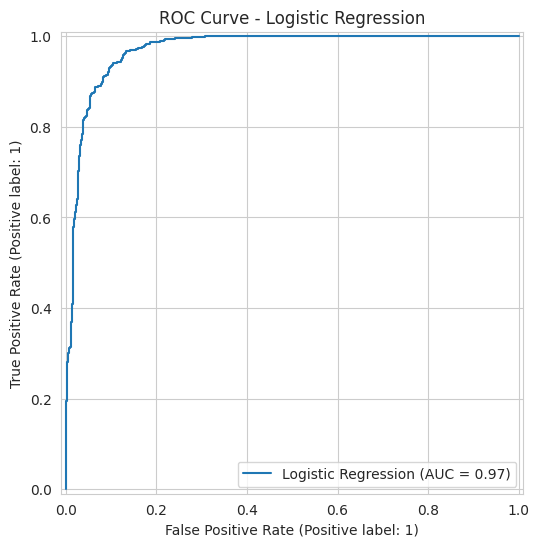

Decision Tree
Accuracy : 0.9674
Precision: 0.9634
Recall   : 0.9717
F1 Score : 0.9675
ROC AUC  : 0.9674

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       460
           1       0.96      0.97      0.97       460

    accuracy                           0.97       920
   macro avg       0.97      0.97      0.97       920
weighted avg       0.97      0.97      0.97       920


Confusion Matrix

[[443  17]
 [ 13 447]]


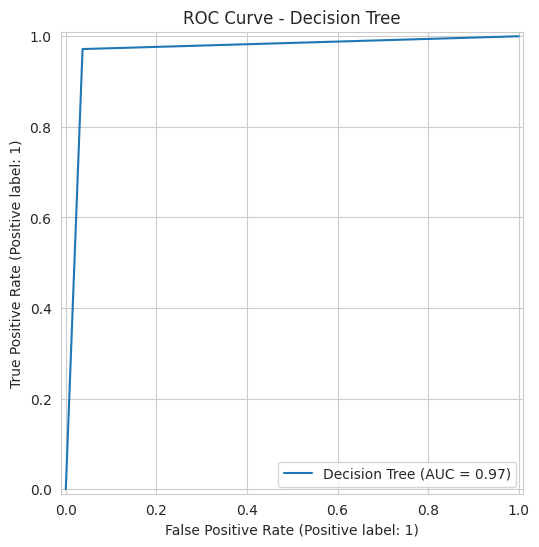

Random Forest
Accuracy : 0.9707
Precision: 0.9822
Recall   : 0.9587
F1 Score : 0.9703
ROC AUC  : 0.9975

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       460
           1       0.98      0.96      0.97       460

    accuracy                           0.97       920
   macro avg       0.97      0.97      0.97       920
weighted avg       0.97      0.97      0.97       920


Confusion Matrix

[[452   8]
 [ 19 441]]


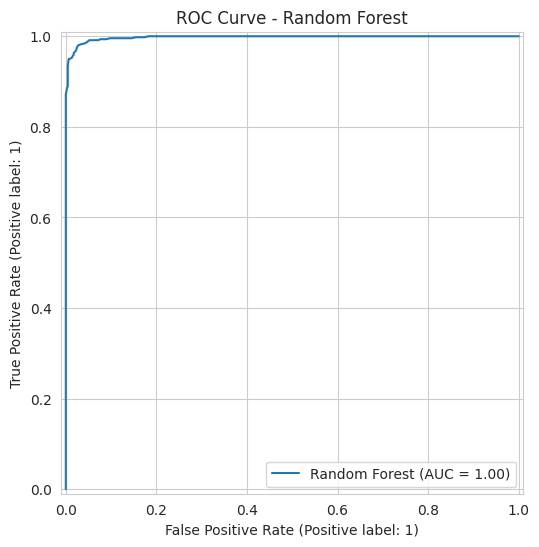

Gradient Boosting
Accuracy : 0.9793
Precision: 0.9868
Recall   : 0.9717
F1 Score : 0.9792
ROC AUC  : 0.9986

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       460
           1       0.99      0.97      0.98       460

    accuracy                           0.98       920
   macro avg       0.98      0.98      0.98       920
weighted avg       0.98      0.98      0.98       920


Confusion Matrix

[[454   6]
 [ 13 447]]


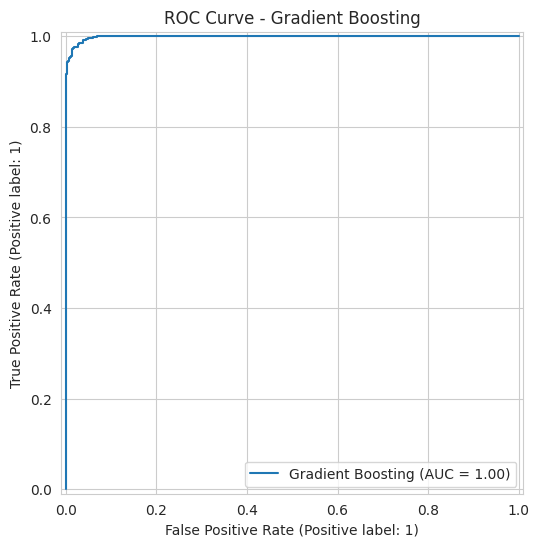

Extra Trees
Accuracy : 0.9217
Precision: 0.9217
Recall   : 0.9217
F1 Score : 0.9217
ROC AUC  : 0.978

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.92      0.92       460
           1       0.92      0.92      0.92       460

    accuracy                           0.92       920
   macro avg       0.92      0.92      0.92       920
weighted avg       0.92      0.92      0.92       920


Confusion Matrix

[[424  36]
 [ 36 424]]


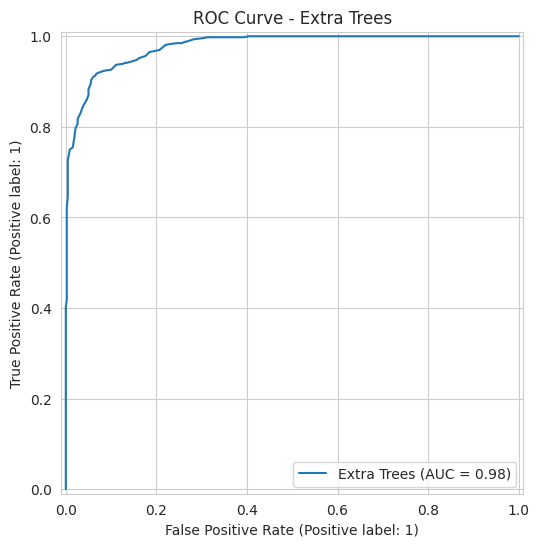

AdaBoost
Accuracy : 0.9587
Precision: 0.9607
Recall   : 0.9565
F1 Score : 0.9586
ROC AUC  : 0.9948

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       460
           1       0.96      0.96      0.96       460

    accuracy                           0.96       920
   macro avg       0.96      0.96      0.96       920
weighted avg       0.96      0.96      0.96       920


Confusion Matrix

[[442  18]
 [ 20 440]]


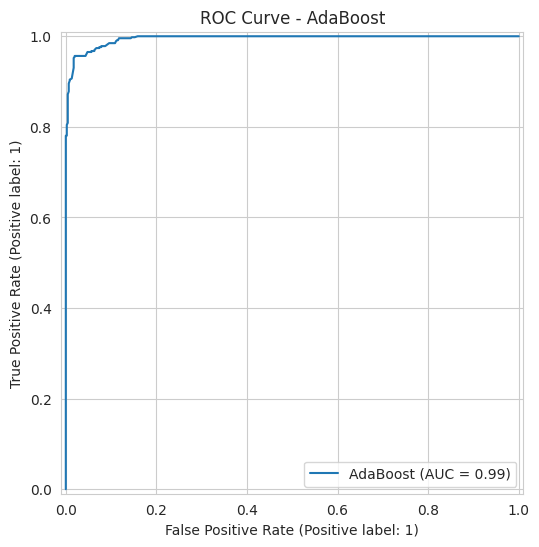

KNN
Accuracy : 0.7467
Precision: 0.7671
Recall   : 0.7087
F1 Score : 0.7367
ROC AUC  : 0.7972

Classification Report

              precision    recall  f1-score   support

           0       0.73      0.78      0.76       460
           1       0.77      0.71      0.74       460

    accuracy                           0.75       920
   macro avg       0.75      0.75      0.75       920
weighted avg       0.75      0.75      0.75       920


Confusion Matrix

[[361  99]
 [134 326]]


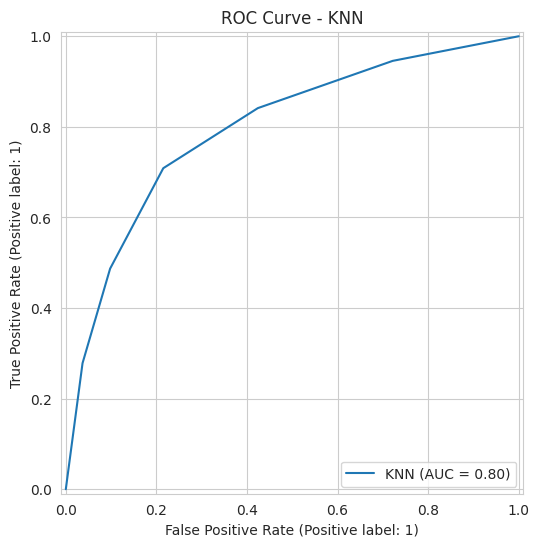

Gaussian NB
Accuracy : 0.6761
Precision: 0.8522
Recall   : 0.4261
F1 Score : 0.5681
ROC AUC  : 0.8339

Classification Report

              precision    recall  f1-score   support

           0       0.62      0.93      0.74       460
           1       0.85      0.43      0.57       460

    accuracy                           0.68       920
   macro avg       0.73      0.68      0.65       920
weighted avg       0.73      0.68      0.65       920


Confusion Matrix

[[426  34]
 [264 196]]


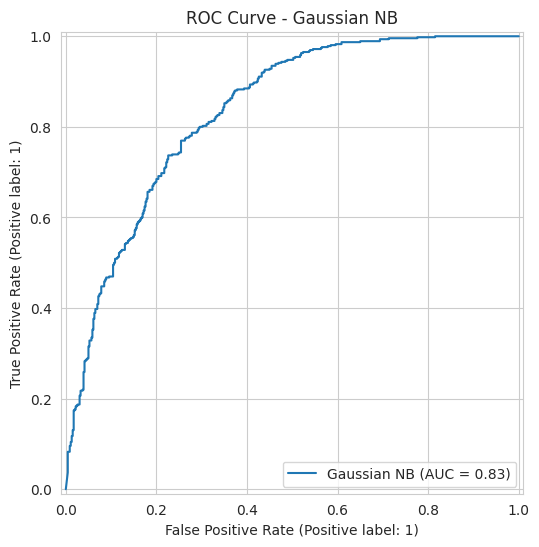

SVM
Accuracy : 0.8924
Precision: 0.8967
Recall   : 0.887
F1 Score : 0.8918
ROC AUC  : 0.9692

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.90      0.89       460
           1       0.90      0.89      0.89       460

    accuracy                           0.89       920
   macro avg       0.89      0.89      0.89       920
weighted avg       0.89      0.89      0.89       920


Confusion Matrix

[[413  47]
 [ 52 408]]


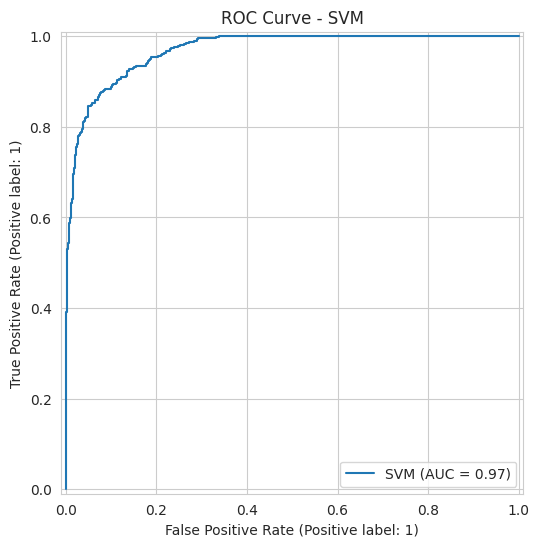


FINAL MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
3    Gradient Boosting  0.979348   0.986755  0.971739  0.979189  0.998620
2        Random Forest  0.970652   0.982183  0.958696  0.970297  0.997545
5             AdaBoost  0.958696   0.960699  0.956522  0.958606  0.994849
4          Extra Trees  0.921739   0.921739  0.921739  0.921739  0.977980
0  Logistic Regression  0.911957   0.907527  0.917391  0.912432  0.970964
8                  SVM  0.892391   0.896703  0.886957  0.891803  0.969168
1        Decision Tree  0.967391   0.963362  0.971739  0.967532  0.967391
7          Gaussian NB  0.676087   0.852174  0.426087  0.568116  0.833946
6                  KNN  0.746739   0.767059  0.708696  0.736723  0.797150

BEST MODEL

Model        Gradient Boosting
Accuracy              0.979348
Precision             0.986755
Recall                0.971739
F1 Score              0.979189
ROC AUC                0.99862
Name: 3, dtype: object


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# =========================================================
# COPY DATA
# =========================================================

data = df.copy()

# =========================================================
# DATE FEATURE ENGINEERING
# =========================================================

data["date"] = pd.to_datetime(data["date"], errors="coerce")

data["year"] = data["date"].dt.year
data["month"] = data["date"].dt.month
data["day"] = data["date"].dt.day

data.drop(columns=["date"], inplace=True)

# =========================================================
# CREATE CLASSIFICATION TARGET
# =========================================================

median_price = data["price"].median()

data["high_price"] = (
    data["price"] > median_price
).astype(int)

# =========================================================
# FEATURES & TARGET
# =========================================================

target = "high_price"

X = data.drop(columns=["price", target])
y = data[target]

# =========================================================
# TRAIN TEST SPLIT (NO DATA LEAKAGE)
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# =========================================================
# HANDLE MISSING VALUES USING TRAINING DATA ONLY
# =========================================================

num_cols = X_train.select_dtypes(include=np.number).columns
cat_cols = X_train.select_dtypes(exclude=np.number).columns

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

# =========================================================
# LABEL ENCODING (FIT ONLY ON TRAIN DATA)
# =========================================================

encoders = {}

for col in cat_cols:

    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col].astype(str))

    mapping = {
        cls: idx
        for idx, cls in enumerate(le.classes_)
    }

    X_test[col] = (
        X_test[col]
        .astype(str)
        .map(mapping)
        .fillna(-1)
        .astype(int)
    )

    encoders[col] = le

# =========================================================
# FEATURE SCALING
# =========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# MODELS
# =========================================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=5000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "Extra Trees":
        ExtraTreesClassifier(random_state=42),

    "AdaBoost":
        AdaBoostClassifier(random_state=42),

    "KNN":
        KNeighborsClassifier(),

    "Gaussian NB":
        GaussianNB(),

    "SVM":
        SVC(probability=True, random_state=42)
}

# =========================================================
# TRAINING & EVALUATION
# =========================================================

results = []

for name, model in models.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    # Use scaled data for models that need scaling
    if name in ["Logistic Regression", "KNN", "SVM", "Gaussian NB"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred, zero_division=0)

    recall = recall_score(y_test, y_pred, zero_division=0)

    f1 = f1_score(y_test, y_pred, zero_division=0)

    roc = roc_auc_score(y_test, y_prob)

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC AUC  :", round(roc, 4))

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("\nConfusion Matrix\n")
    print(confusion_matrix(y_test, y_pred))

    # ROC Curve
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name)

    plt.title(f"ROC Curve - {name}")
    plt.grid(True)
    plt.show()

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc
    ])

# =========================================================
# FINAL RESULT TABLE
# =========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

results_df = results_df.sort_values(
    by="ROC AUC",
    ascending=False
)

print("\n==============================")
print("FINAL MODEL COMPARISON")
print("==============================")

print(results_df)

# =========================================================
# BEST MODEL
# =========================================================

best = results_df.iloc[0]

print("\nBEST MODEL\n")
print(best)

## Thanks........Please Upvote